In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 200

# ── Config ────────────────────────────────────────────────────────────────────
FILES = {
    'DoS':        'DoS.csv',
    'DDoS':       'DDoS.csv',
    'Port Scan':  'PortScan.csv',
    'Brute Force':'BruteForce.csv',
}

FEATURES = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Max',
    'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length',
    'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length',
    'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
    'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
    'ACK Flag Count', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
    'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean',
    'Active Max', 'Active Min', 'Idle Mean',
]

OUTPUT_DIR = 'AttackTypeEDAPlots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COLORS = {
    'DoS':         "#FF1900",
    'DDoS':        "#49E622",
    'Port Scan':   '#2980B9',
    'Brute Force': "#FF00F7",
}


In [6]:

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading CSVs...")
dfs = {}
for label, path in FILES.items():
    dfs[label] = pd.read_csv(path, usecols=lambda c: c in FEATURES + ['Attack Type'])
    print(f"  {label}: {len(dfs[label])} rows, {dfs[label].shape[1]} cols")

combined = pd.concat(dfs.values(), keys=dfs.keys()).reset_index(level=0).rename(columns={'level_0': 'Class'})


Loading CSVs...
  DoS: 193647 rows, 47 cols
  DDoS: 128014 rows, 47 cols
  Port Scan: 90694 rows, 47 cols
  Brute Force: 9150 rows, 47 cols


In [7]:

# ── 1. Descriptive statistics per class ───────────────────────────────────────
print("\n── Descriptive Statistics ──")
for label, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"  {label}")
    print('='*60)
    print(df[FEATURES].describe().T.to_string())



── Descriptive Statistics ──

  DoS
                                count          mean           std        min           25%           50%           75%           max
Destination Port             193647.0  8.000000e+01  0.000000e+00  80.000000  8.000000e+01  8.000000e+01  8.000000e+01  8.000000e+01
Flow Duration                193647.0  7.267150e+07  3.877159e+07   1.000000  6.707117e+07  8.587800e+07  9.905675e+07  1.199686e+08
Total Fwd Packets            193647.0  6.341549e+00  2.314453e+00   1.000000  5.000000e+00  6.000000e+00  8.000000e+00  2.300000e+01
Total Backward Packets       193647.0  5.287105e+00  2.146527e+00   0.000000  5.000000e+00  6.000000e+00  7.000000e+00  1.200000e+01
Total Length of Fwd Packets  193647.0  3.939398e+02  3.801790e+02   0.000000  3.190000e+02  3.540000e+02  3.810000e+02  6.910000e+03
Total Length of Bwd Packets  193647.0  9.625120e+03  4.313877e+03   0.000000  1.159500e+04  1.159500e+04  1.159500e+04  1.455600e+04
Fwd Packet Length Max        193


Plotting feature mean heatmap...


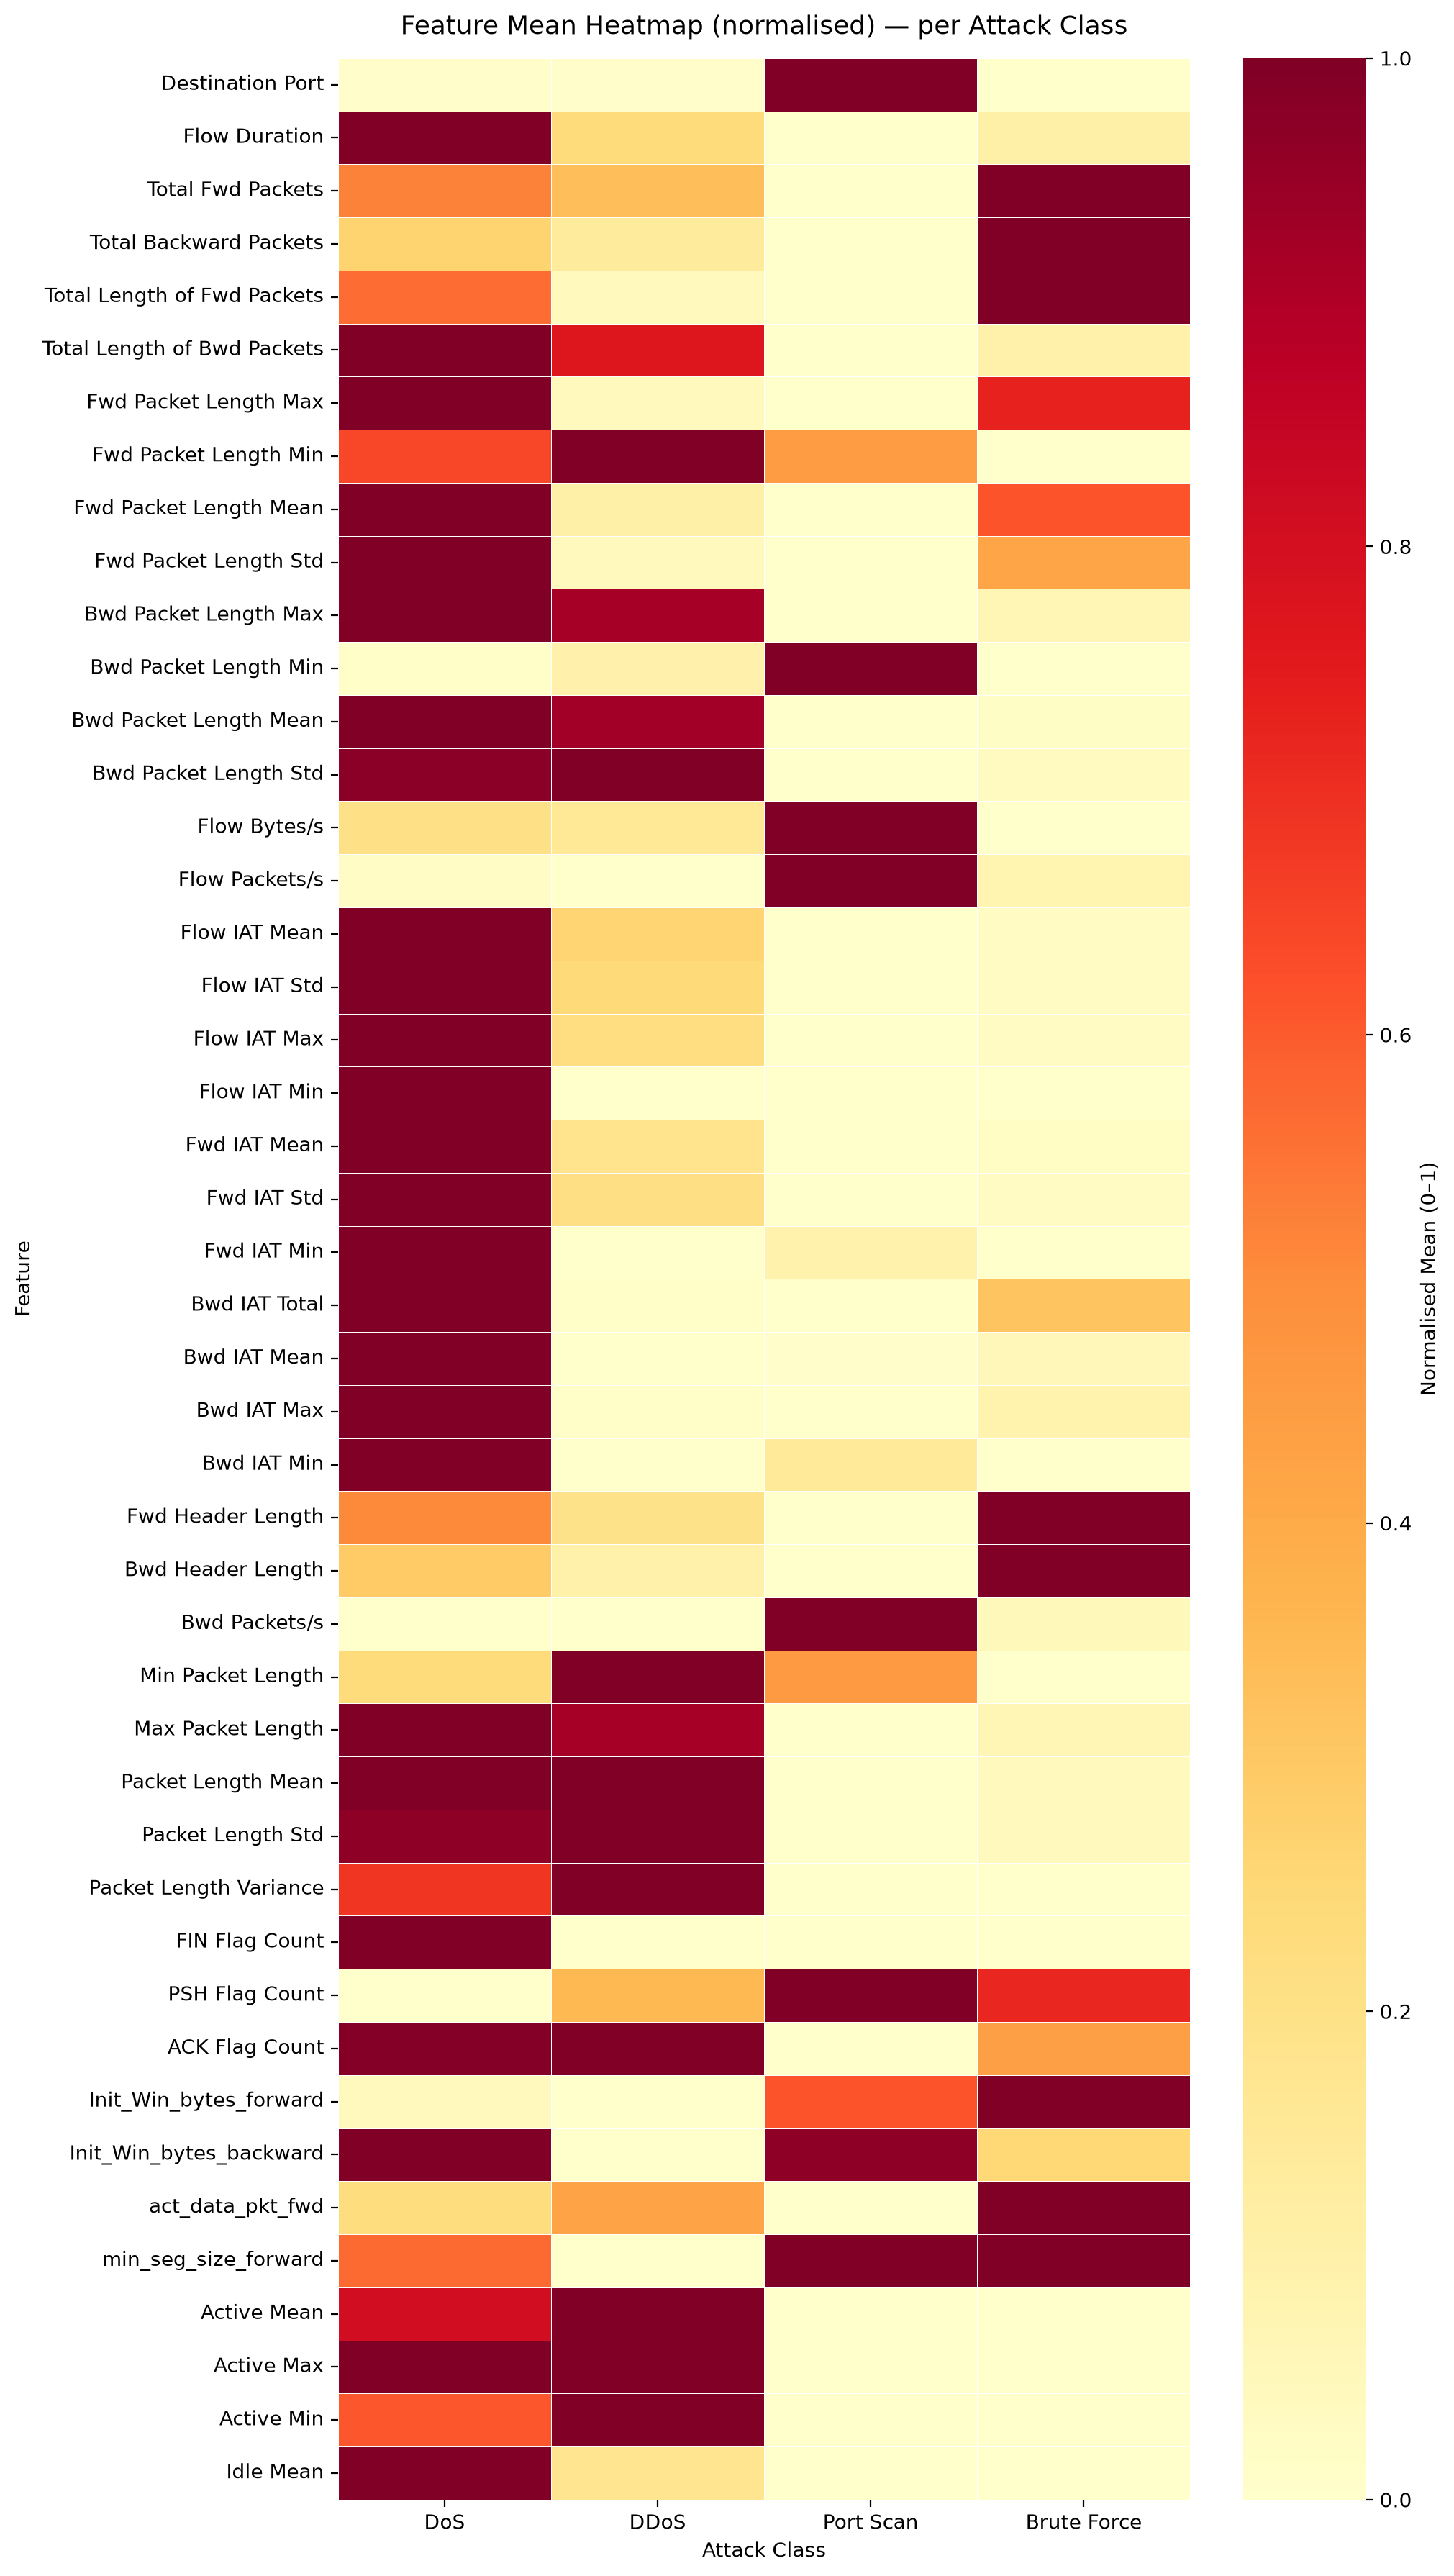

In [8]:

# ── 2. Class-wise feature means (heatmap) ────────────────────────────────────
print("\nPlotting feature mean heatmap...")
means = pd.DataFrame({label: df[FEATURES].mean() for label, df in dfs.items()})
means_norm = (means - means.min(axis=1).values.reshape(-1,1)) / \
             (means.max(axis=1) - means.min(axis=1) + 1e-9).values.reshape(-1,1)

fig, ax = plt.subplots(figsize=(10, 18))
sns.heatmap(means_norm, annot=False, cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Normalised Mean (0–1)'})
ax.set_title('Feature Mean Heatmap (normalised) — per Attack Class', fontsize=13, pad=12)
ax.set_xlabel('Attack Class')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_feature_mean_heatmap.png')
plt.show()


Plotting violin plots...


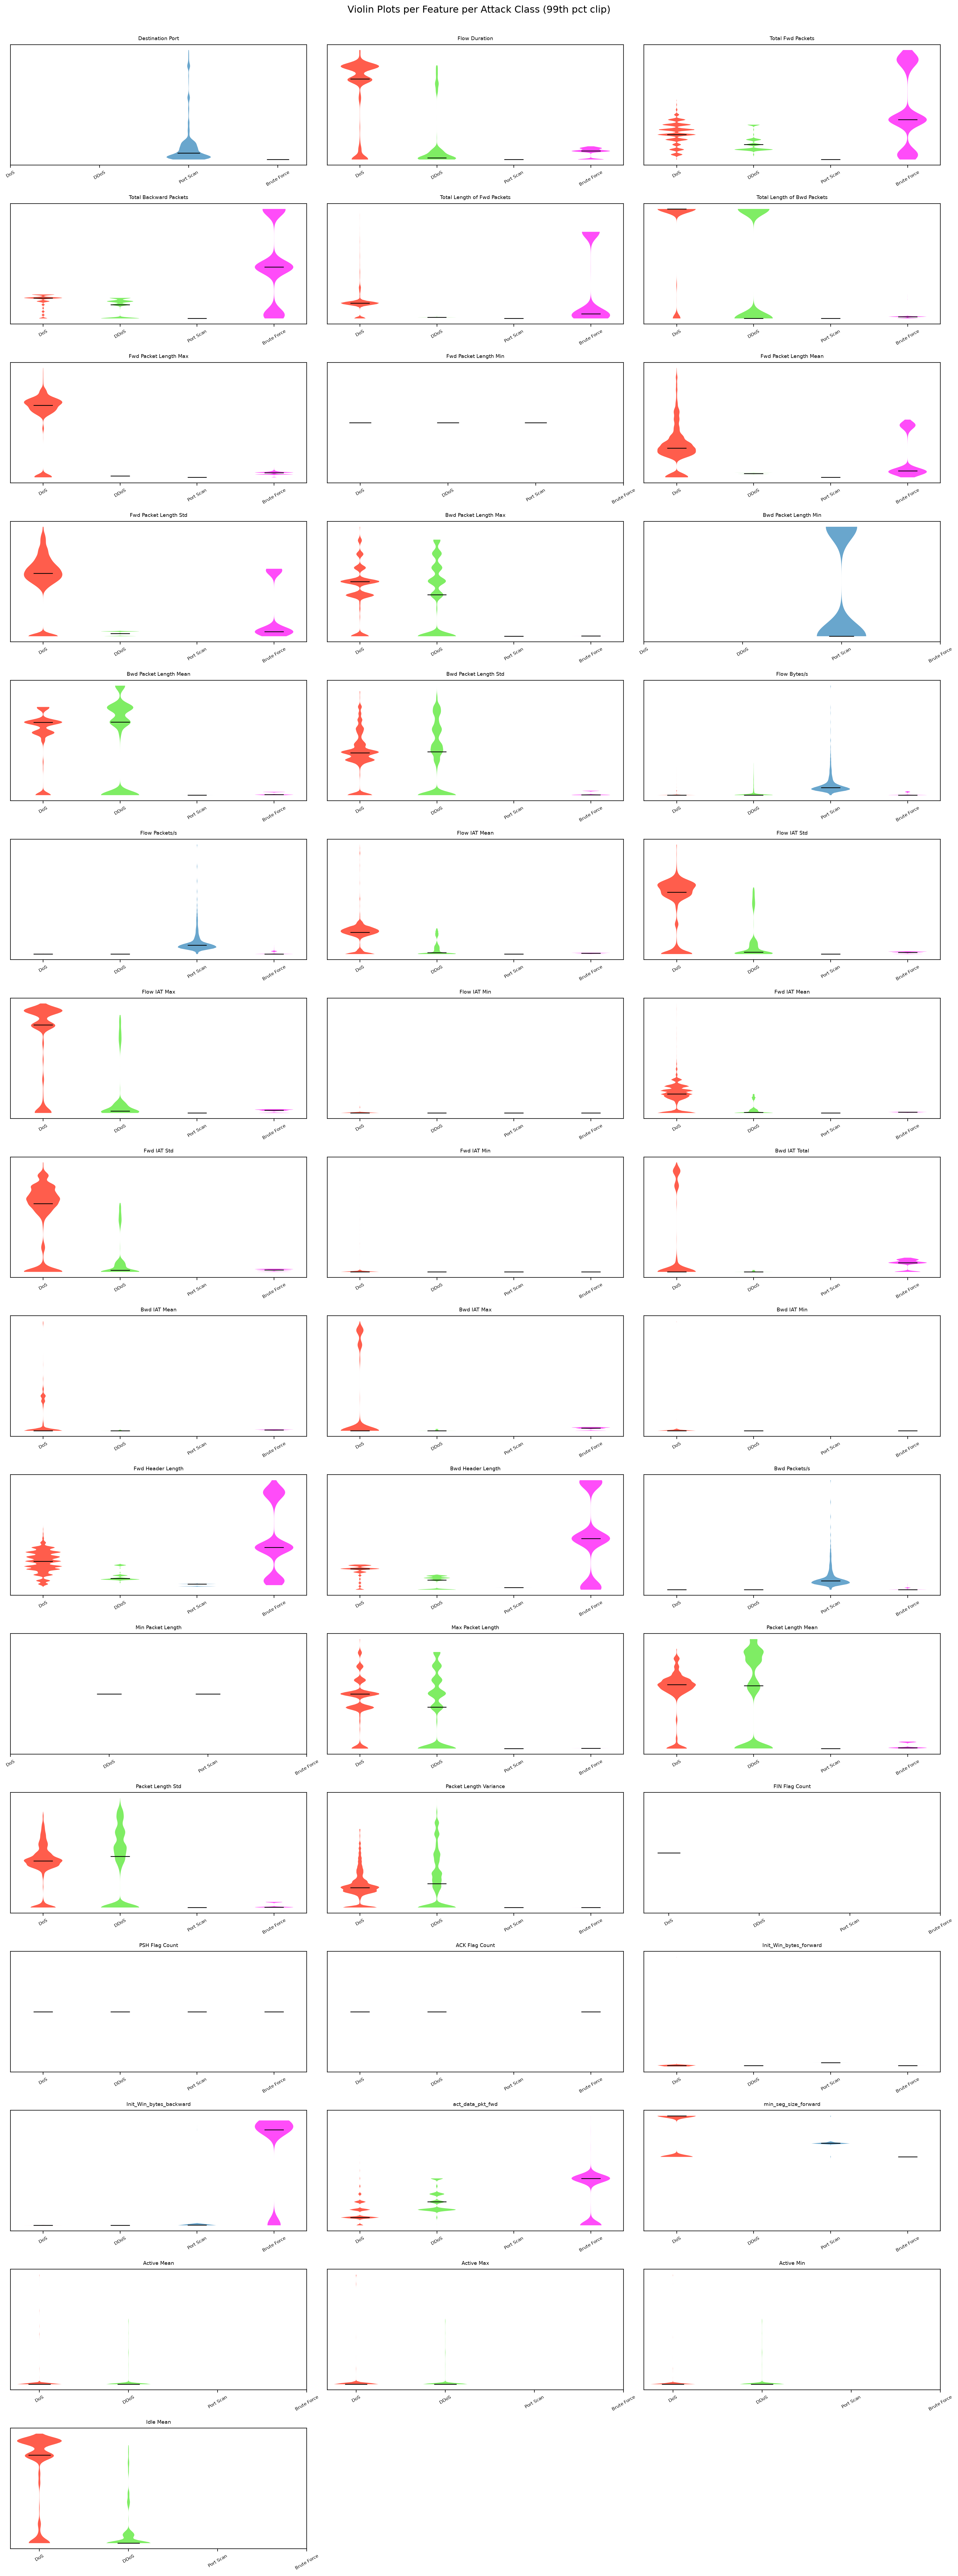

In [16]:
# ── 3. Violin plots per feature per class ────────────────────────────────────
print("Plotting violin plots...")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data_by_class = []
    labels_by_class = []
    for label, df in dfs.items():
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        vals = vals[vals < vals.quantile(0.99)]
        data_by_class.append(vals.values)
        labels_by_class.append(label)
    parts = ax.violinplot(data_by_class, positions=range(len(labels_by_class)),
                          showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(COLORS.values())[j])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1)
    ax.set_xticks(range(len(labels_by_class)))
    ax.set_xticklabels(labels_by_class, fontsize=5, rotation=30)
    ax.set_title(feat, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Violin Plots per Feature per Attack Class (99th pct clip)', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_violin_plots.png', bbox_inches='tight')
plt.show()

Plotting box plots...


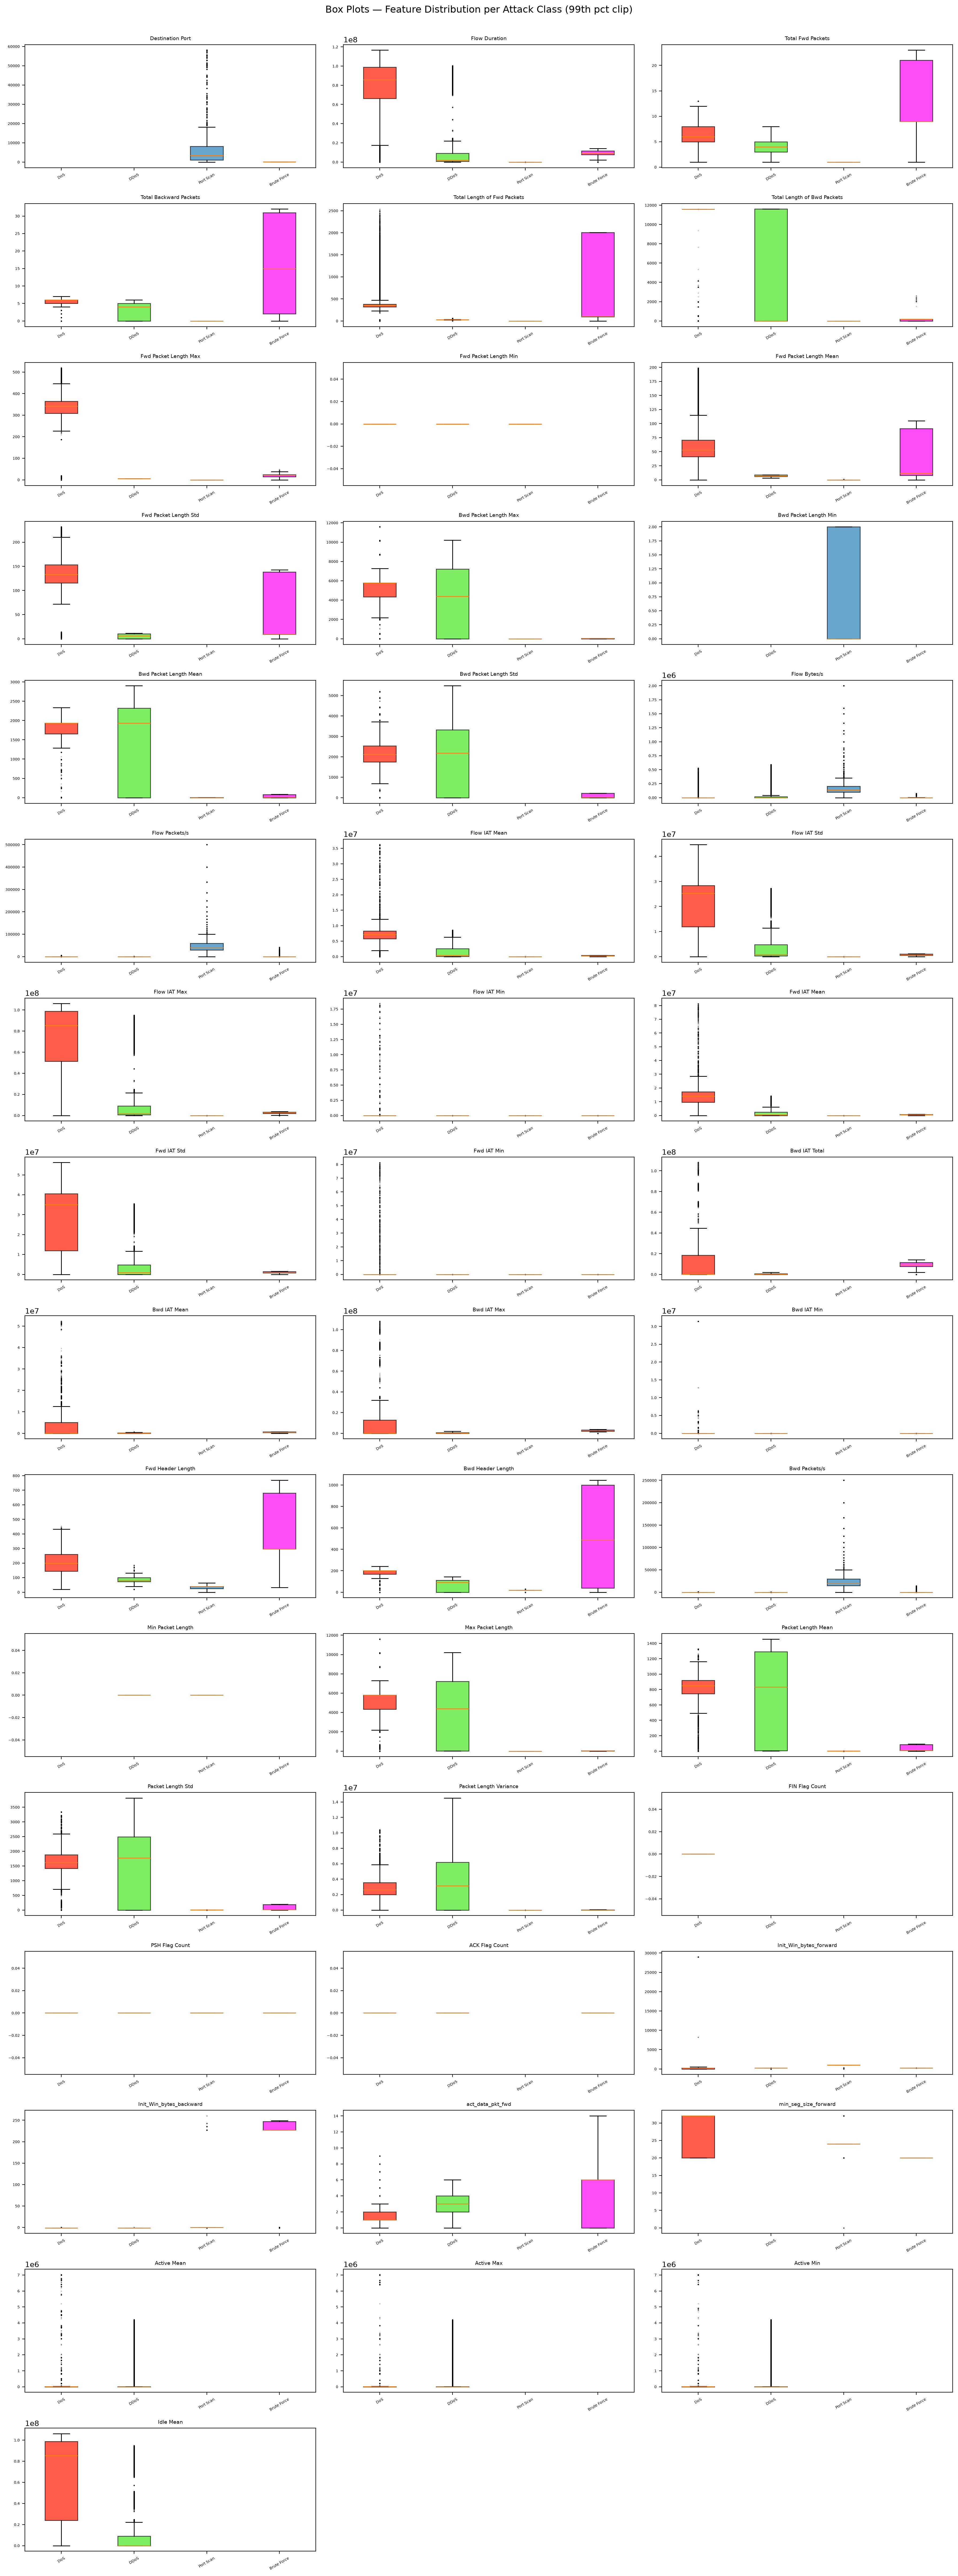

In [10]:

# ── 4. Box plots — per feature across classes ─────────────────────────────────
print("Plotting box plots...")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data_by_class = []
    labels_by_class = []
    for label, df in dfs.items():
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        vals = vals[vals < vals.quantile(0.99)]
        data_by_class.append(vals.values)
        labels_by_class.append(label)
    bp = ax.boxplot(data_by_class, patch_artist=True, tick_labels=labels_by_class,
                    flierprops=dict(marker='.', markersize=1, alpha=0.3))
    for patch, label in zip(bp['boxes'], labels_by_class):
        patch.set_facecolor(COLORS[label])
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=7)
    ax.tick_params(labelsize=5)
    ax.set_xticklabels(labels_by_class, rotation=30, fontsize=5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots — Feature Distribution per Attack Class (99th pct clip)', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_boxplots.png', bbox_inches='tight')
plt.show()


Plotting correlation matrices...


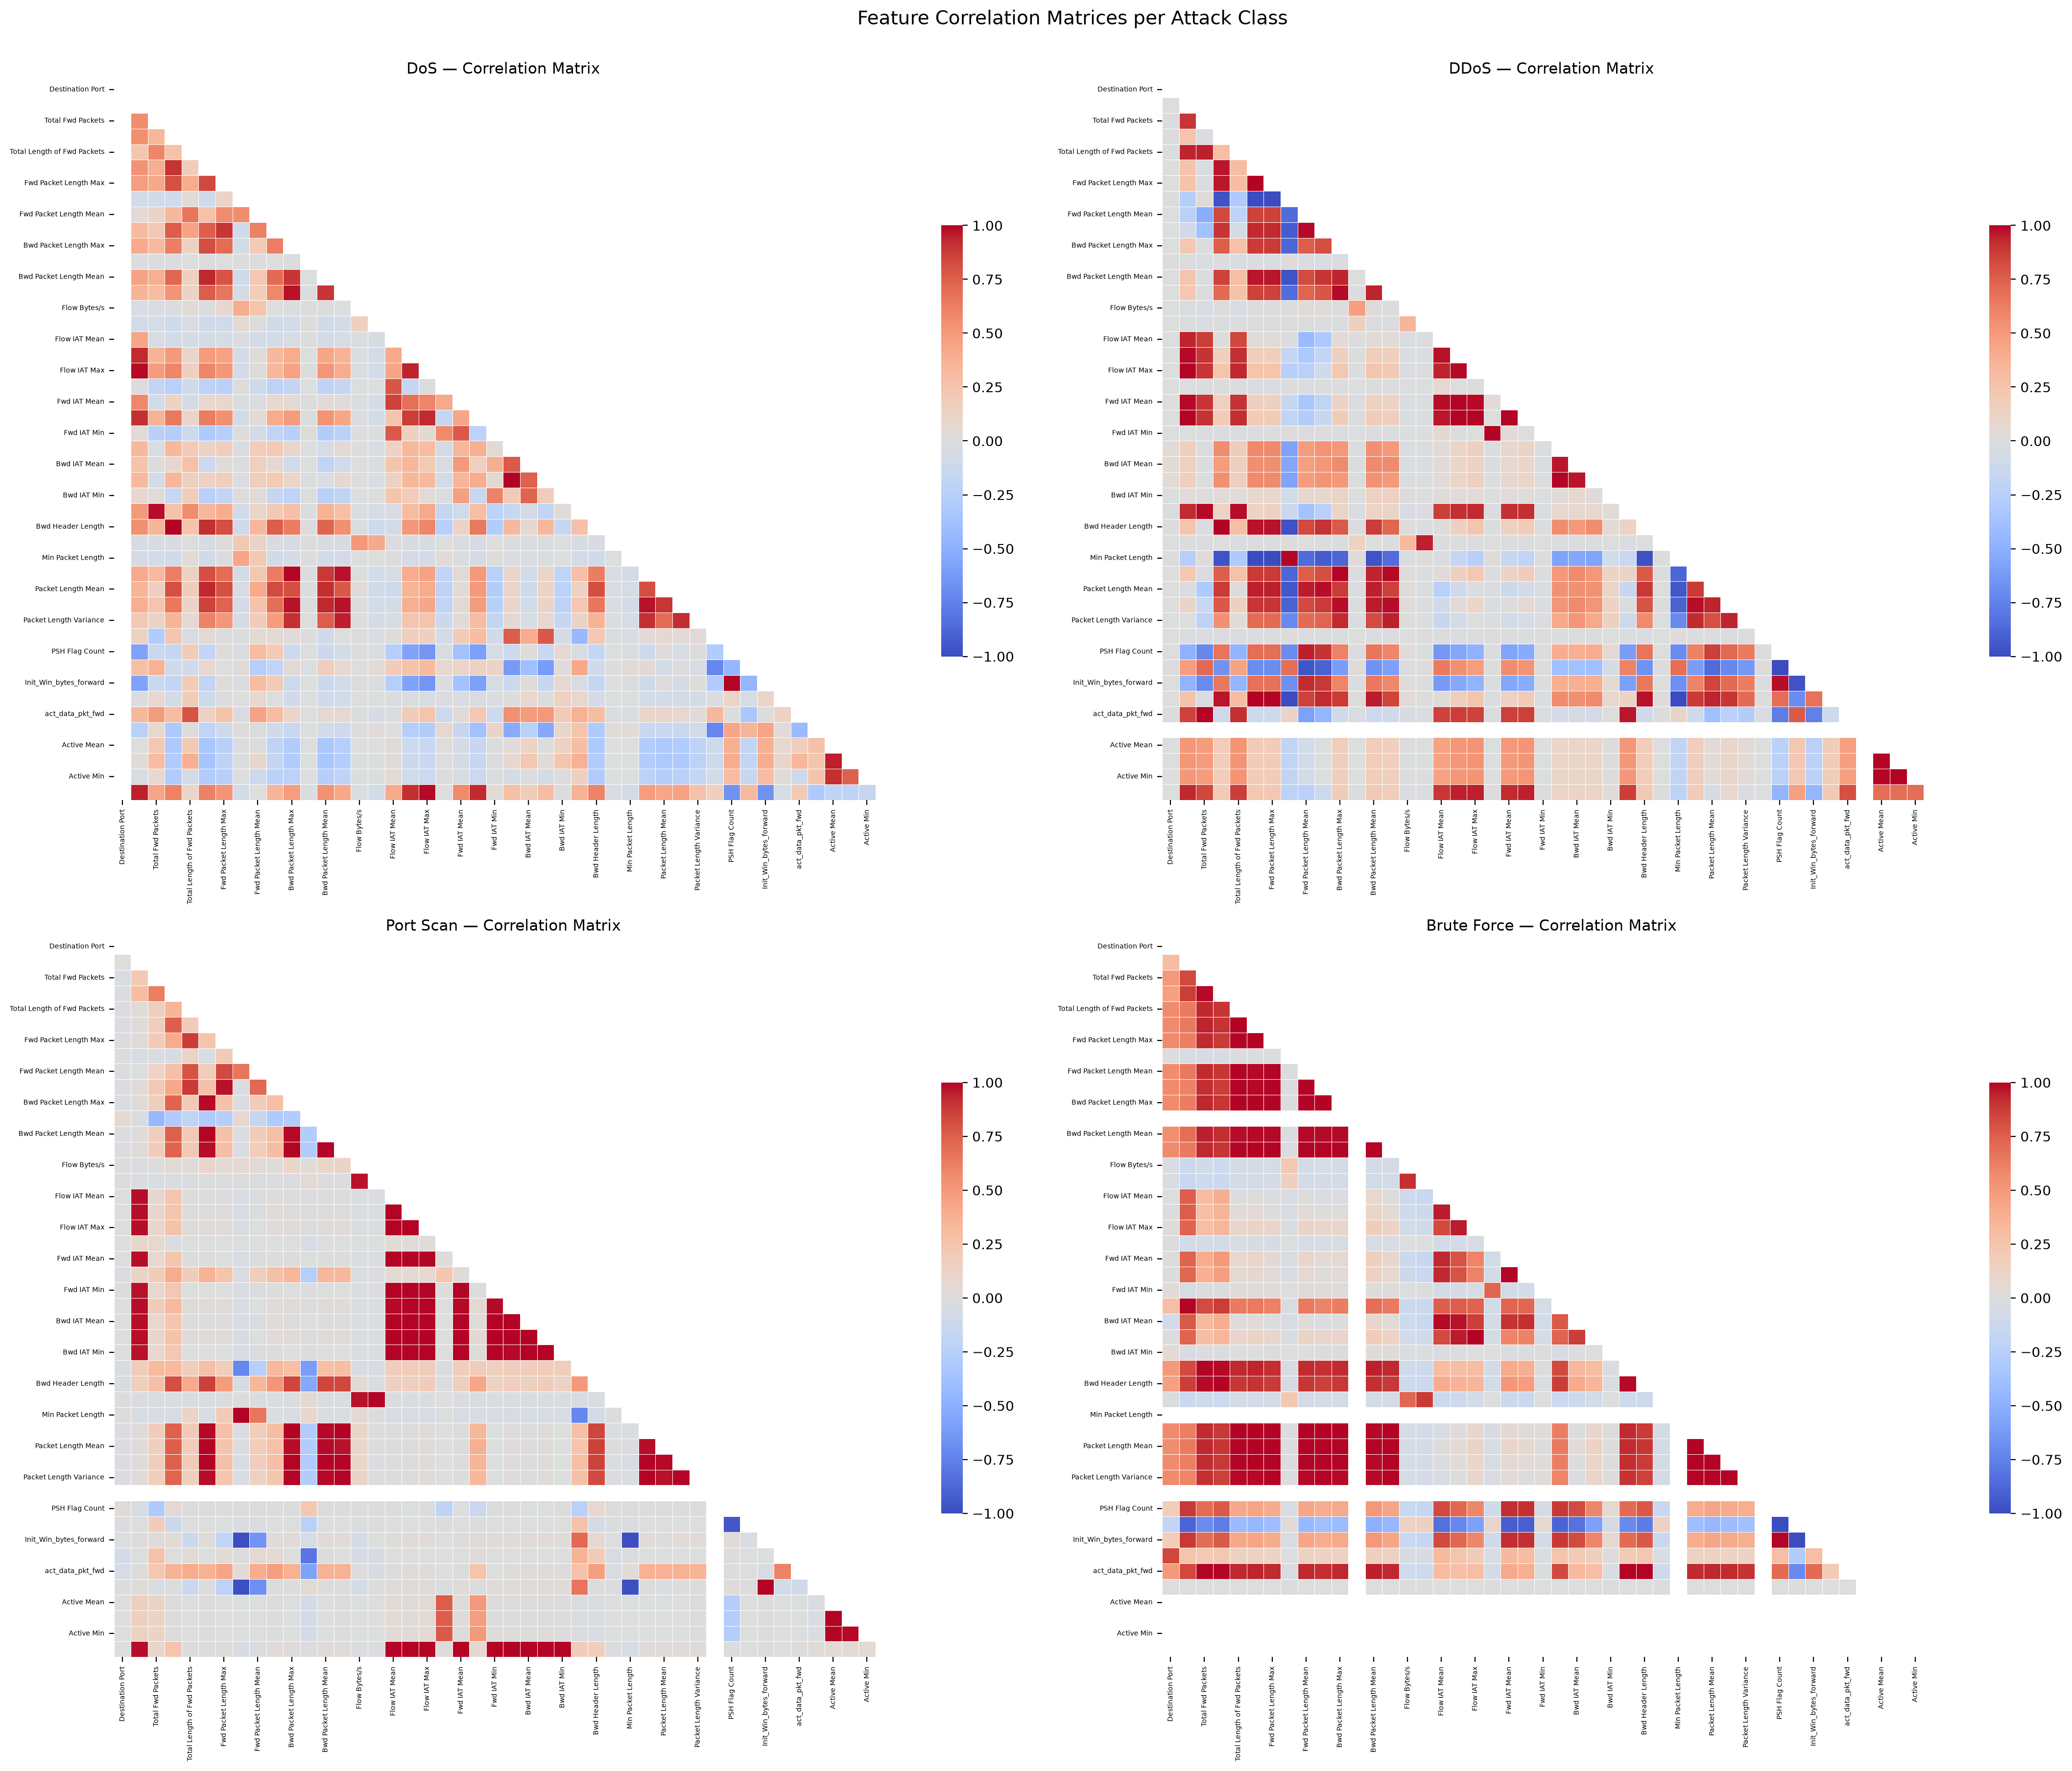

In [11]:

# ── 5. Correlation matrix per class ──────────────────────────────────────────
print("Plotting correlation matrices...")
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for i, (label, df) in enumerate(dfs.items()):
    corr = df[FEATURES].replace([np.inf, -np.inf], np.nan).dropna().corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=axes[i], cmap='coolwarm', center=0,
                linewidths=0.2, annot=False, cbar_kws={'shrink': 0.6},
                vmin=-1, vmax=1)
    axes[i].set_title(f'{label} — Correlation Matrix', fontsize=11)
    axes[i].tick_params(labelsize=5)

plt.suptitle('Feature Correlation Matrices per Attack Class', fontsize=14, y=1.002)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_correlation_matrices.png', bbox_inches='tight', dpi=300)
plt.show()


Computing ANOVA F-statistics for feature discrimination...


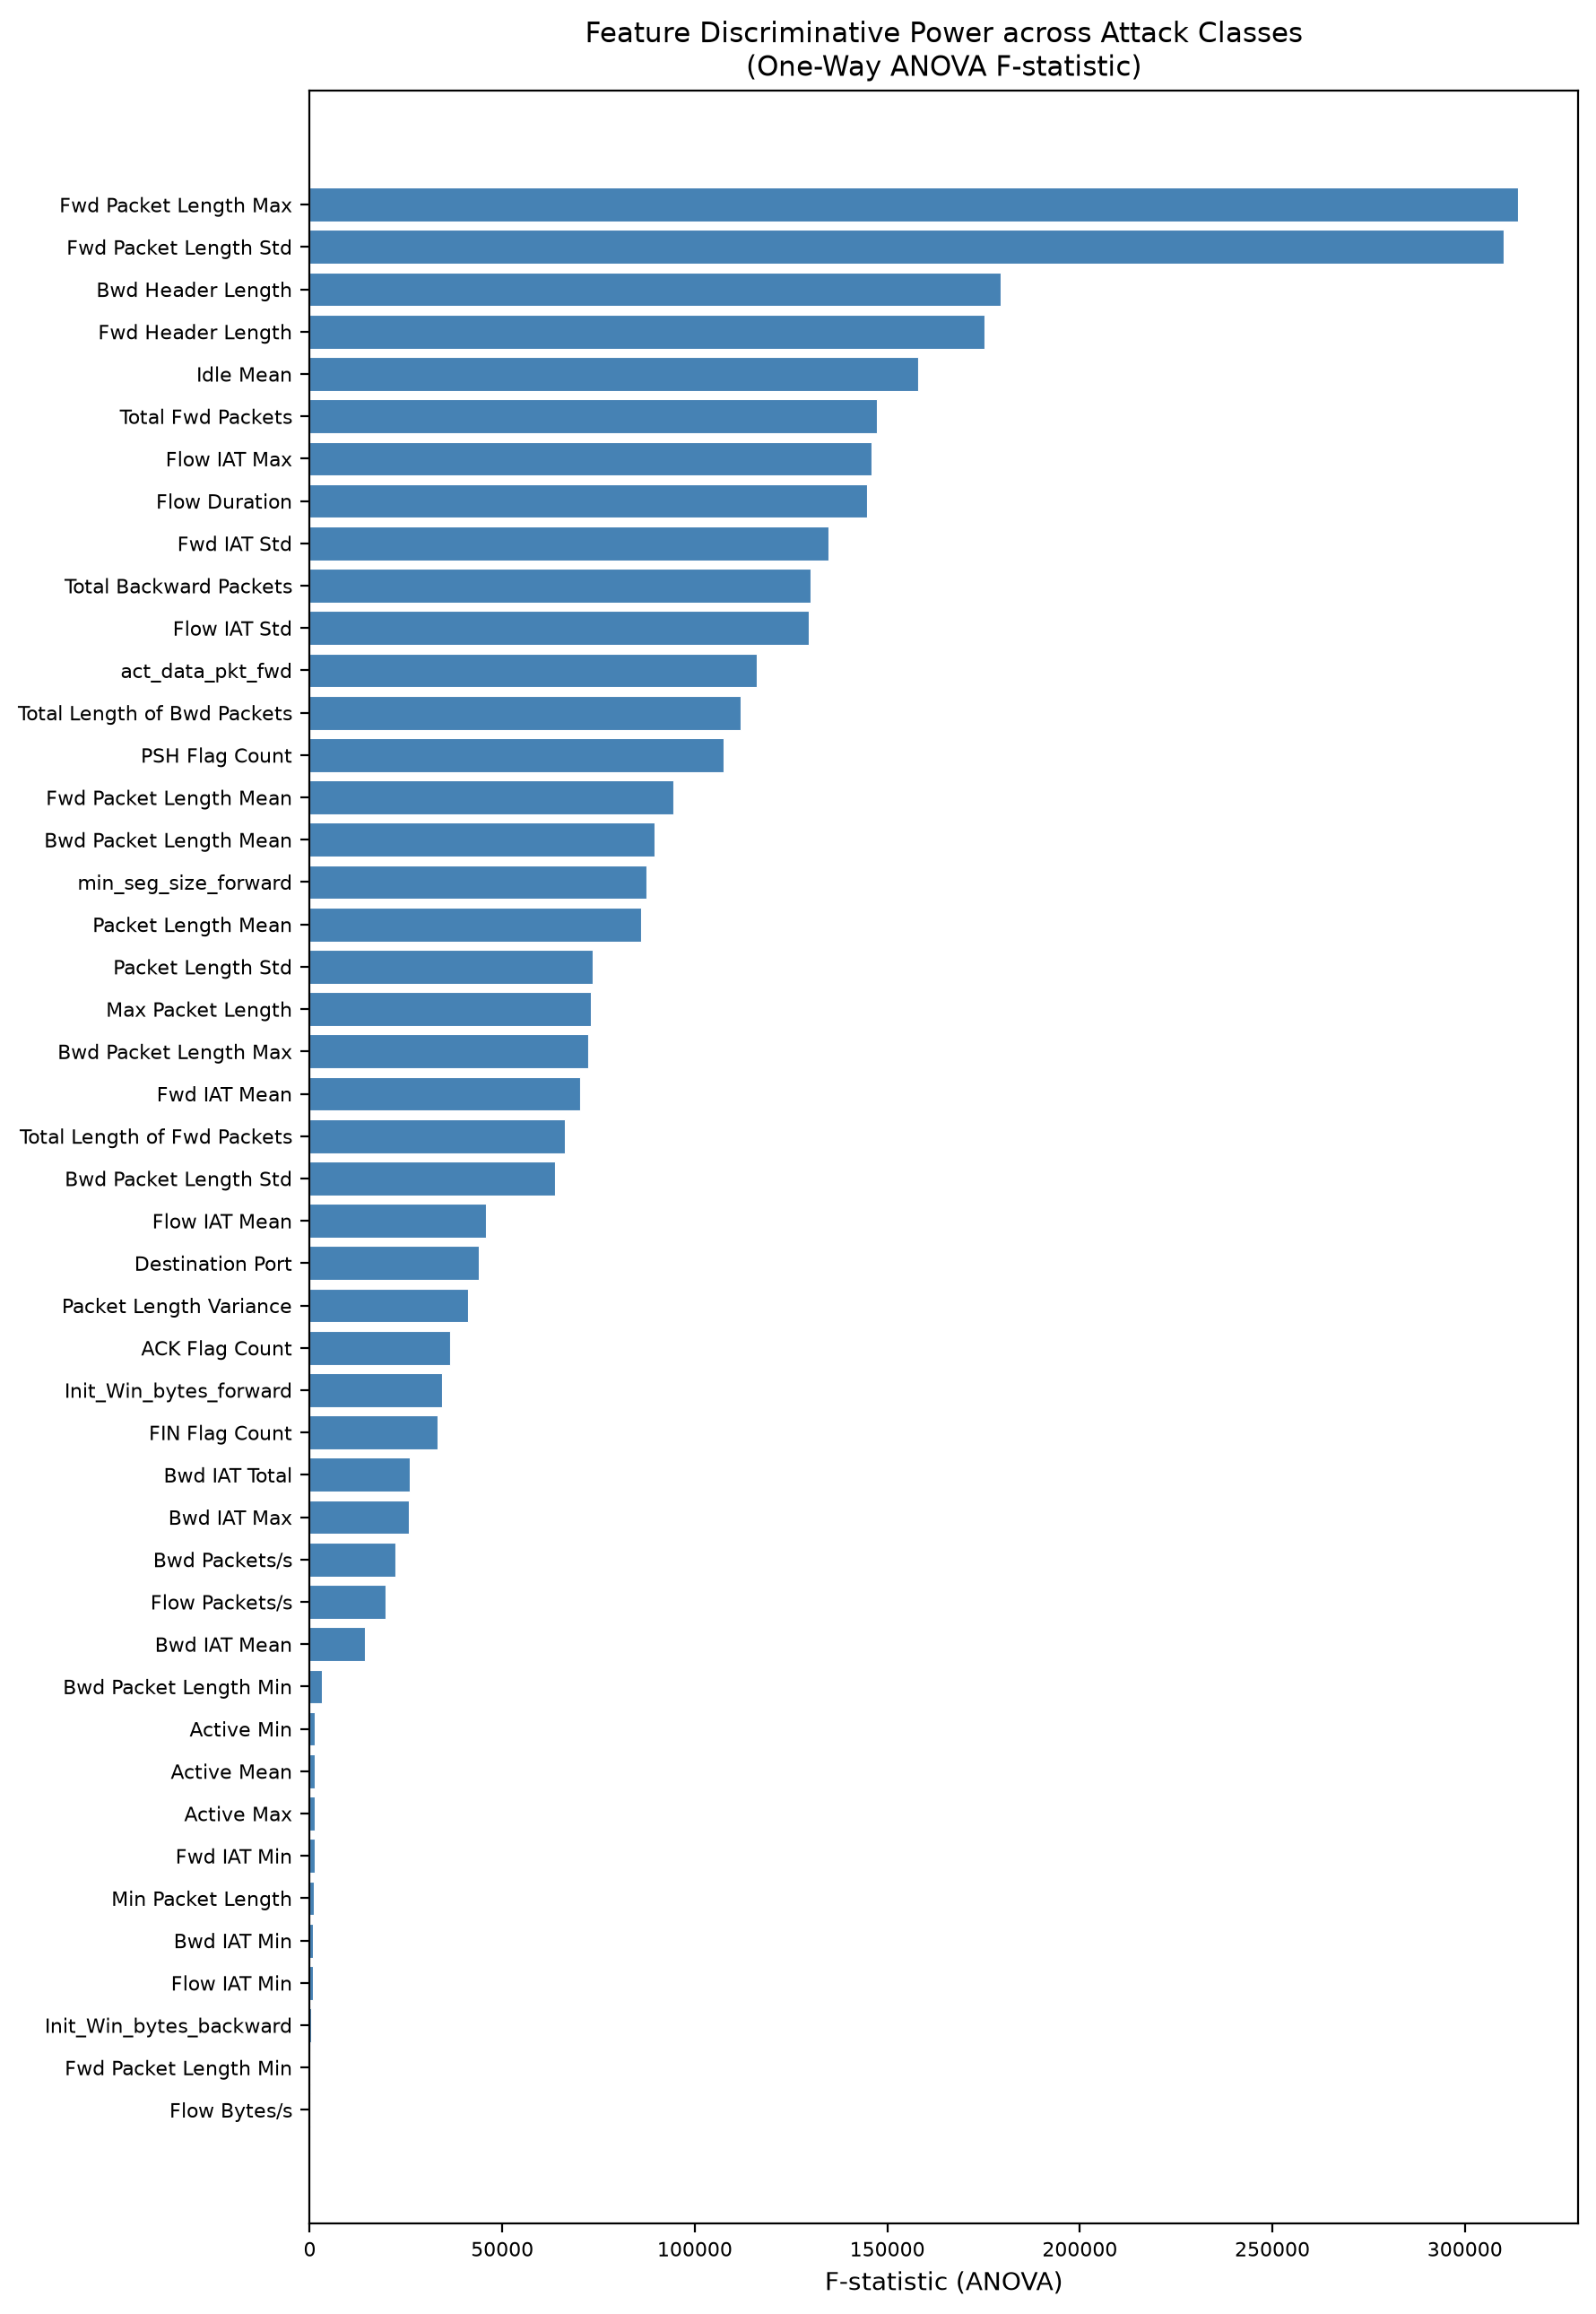


Top 10 discriminating features:
Fwd Packet Length Max     313705.927022
Fwd Packet Length Std     310149.128021
Bwd Header Length         179333.399464
Fwd Header Length         175183.430370
Idle Mean                 157955.603786
Total Fwd Packets         147278.524246
Flow IAT Max              145904.489377
Flow Duration             144622.489491
Fwd IAT Std               134702.102361
Total Backward Packets    130101.569848


In [12]:

# ── 6. Top discriminating features (F-statistic via ANOVA) ───────────────────
print("Computing ANOVA F-statistics for feature discrimination...")
from scipy import stats

f_scores = {}
for feat in FEATURES:
    groups = []
    for df in dfs.values():
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna().values
        groups.append(vals)
    try:
        f, p = stats.f_oneway(*groups)
        f_scores[feat] = f if np.isfinite(f) else 0
    except Exception:
        f_scores[feat] = 0

f_series = pd.Series(f_scores).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 13))
bars = ax.barh(f_series.index, f_series.values, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('F-statistic (ANOVA)', fontsize=10)
ax.set_title('Feature Discriminative Power across Attack Classes\n(One-Way ANOVA F-statistic)', fontsize=11)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_anova_f_scores.png', bbox_inches='tight')
plt.show()

print(f"\nTop 10 discriminating features:")
print(f_series.sort_values(ascending=False).head(10).to_string())


Plotting pairplot for top 5 discriminating features...


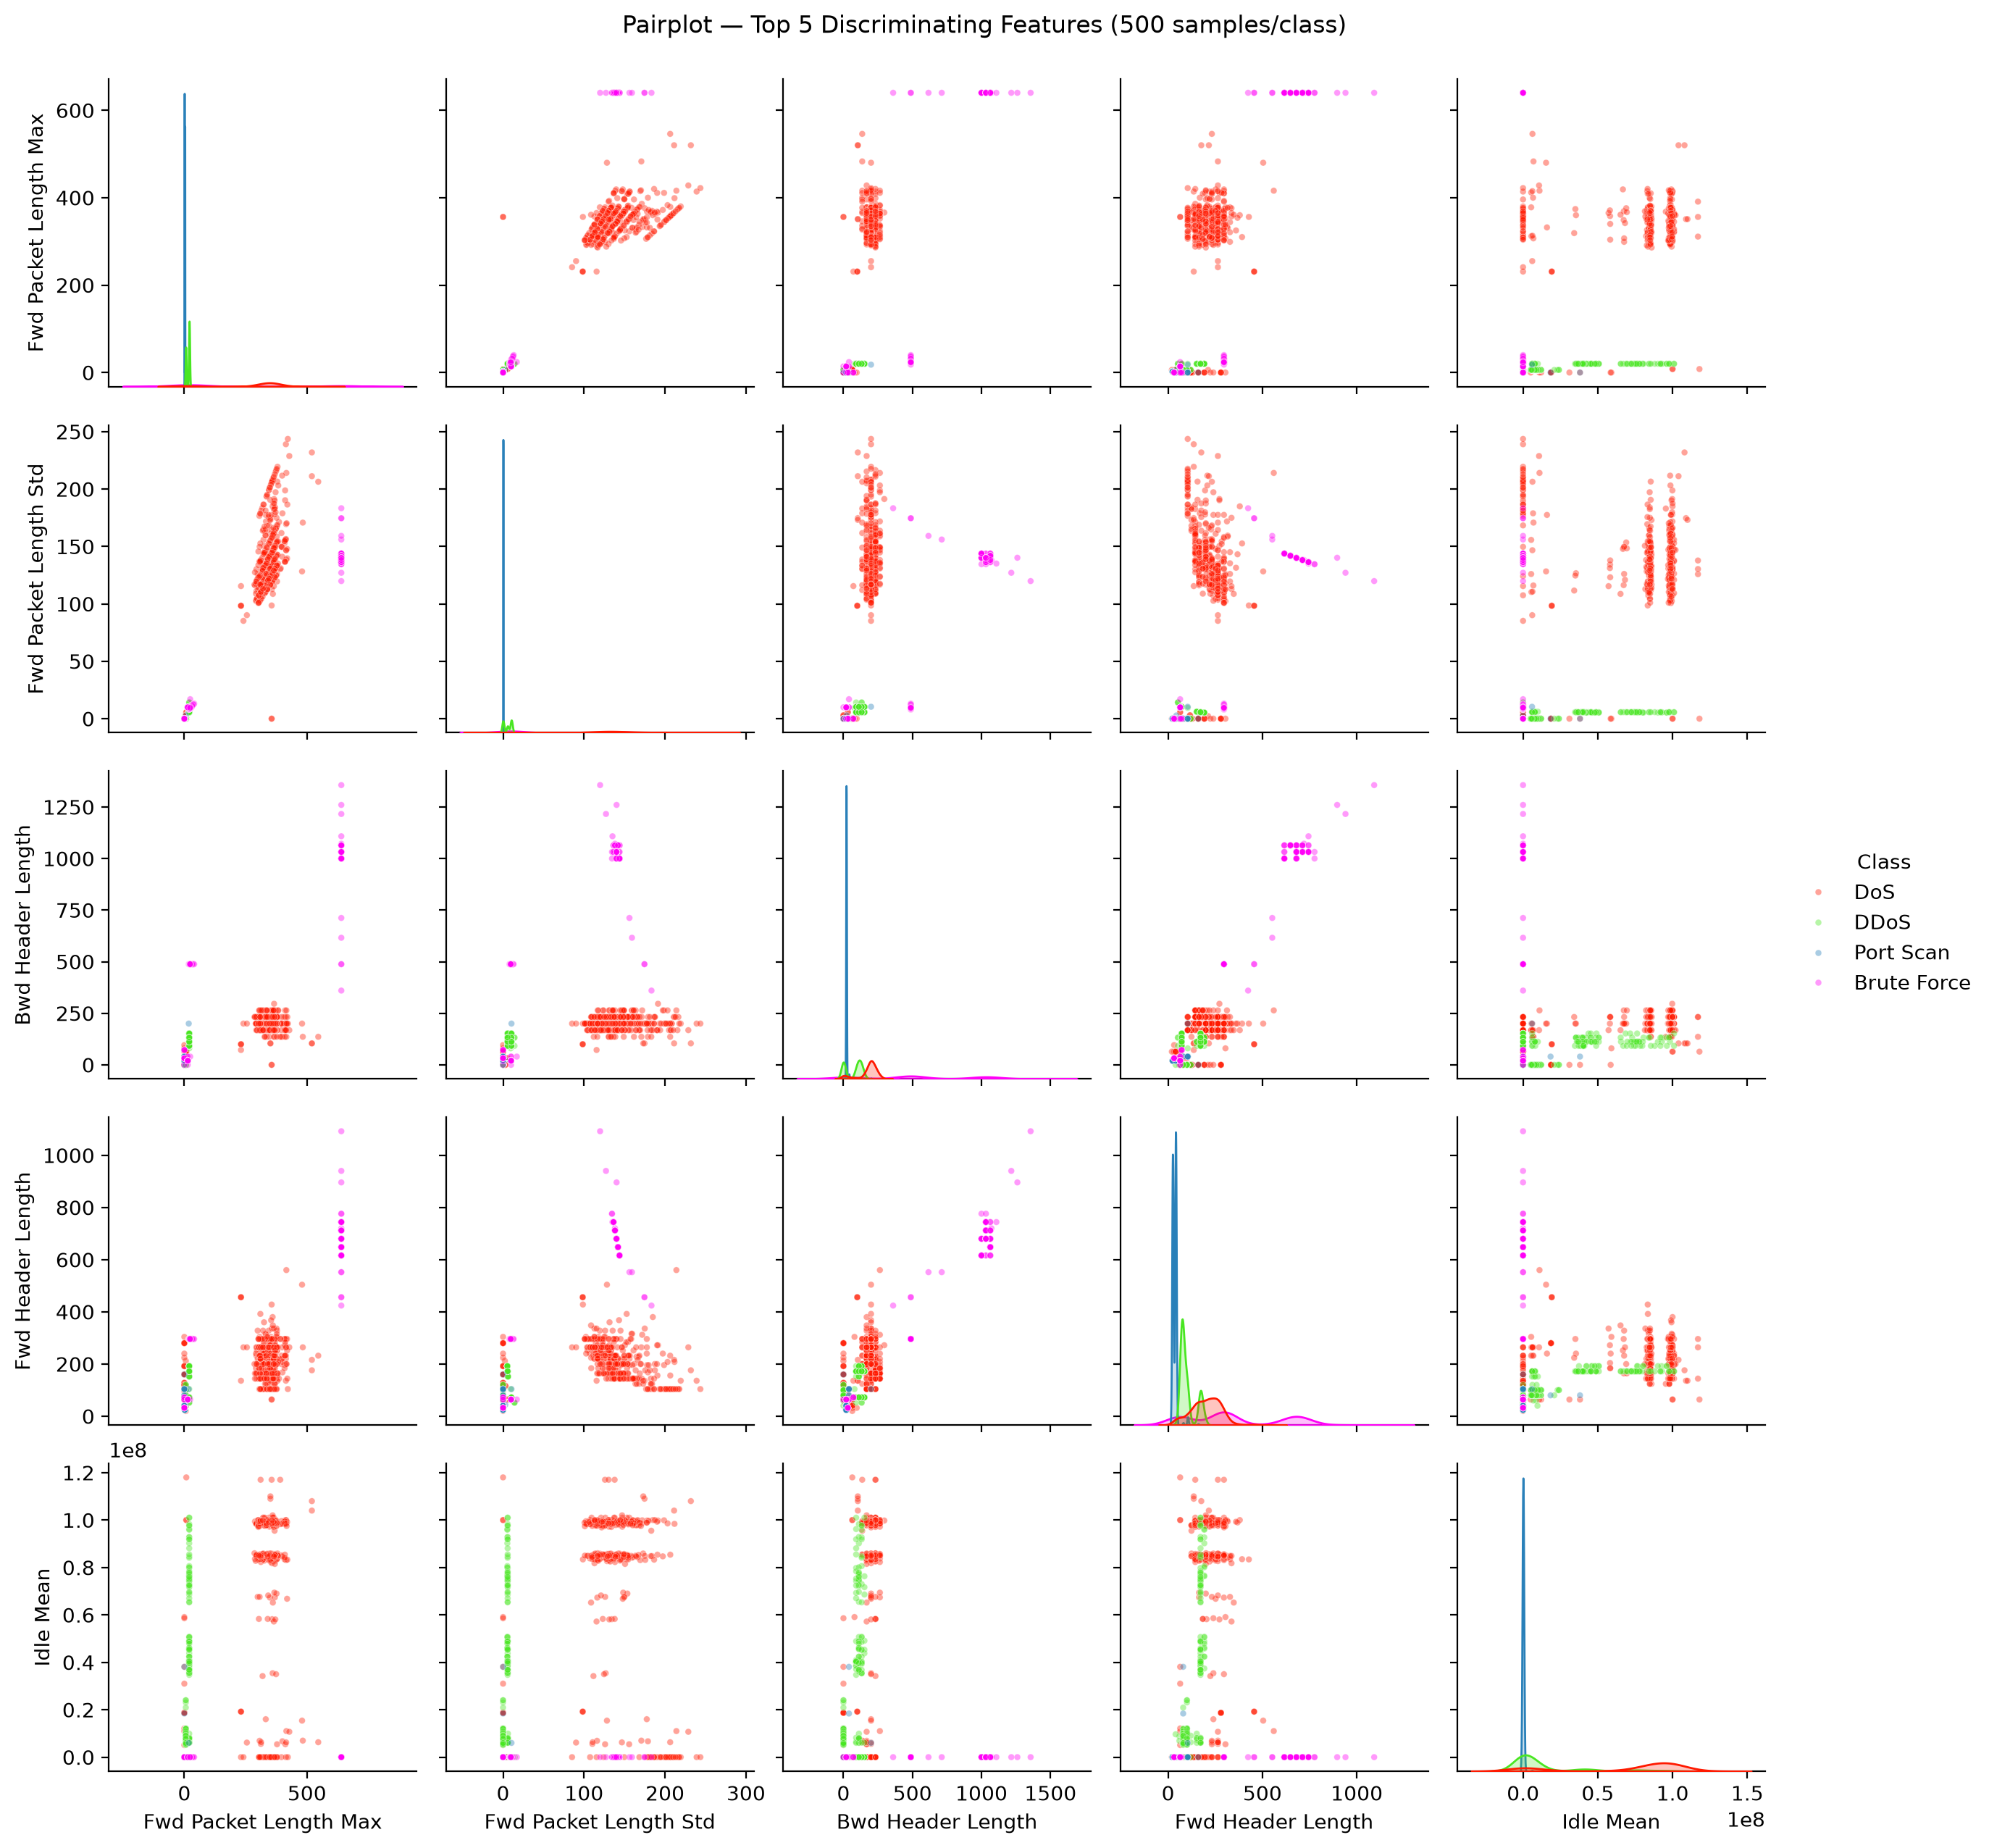

In [ ]:

# ── 7. Pairplot on top 5 discriminating features ──────────────────────────────
print("Plotting pairplot for top 5 discriminating features...")
top5 = f_series.sort_values(ascending=False).head(5).index.tolist()
sample = pd.concat([
    df.sample(min(500, len(df)), random_state=42).assign(Class=label)
    for label, df in dfs.items()
]).reset_index(drop=True)
sample_clean = sample[top5 + ['Class']].replace([np.inf, -np.inf], np.nan).dropna()

palette = {k: v for k, v in COLORS.items()}
g = sns.pairplot(sample_clean, hue='Class', vars=top5, palette=palette,
                 plot_kws={'alpha': 0.4, 's': 10}, diag_kind='kde')
g.fig.suptitle('Pairplot — Top 5 Discriminating Features (500 samples/class)', y=1.02, fontsize=12)
plt.savefig(f'{OUTPUT_DIR}/06_pairplot_top5.png', bbox_inches='tight')
plt.show()


Plotting flow volume profile...


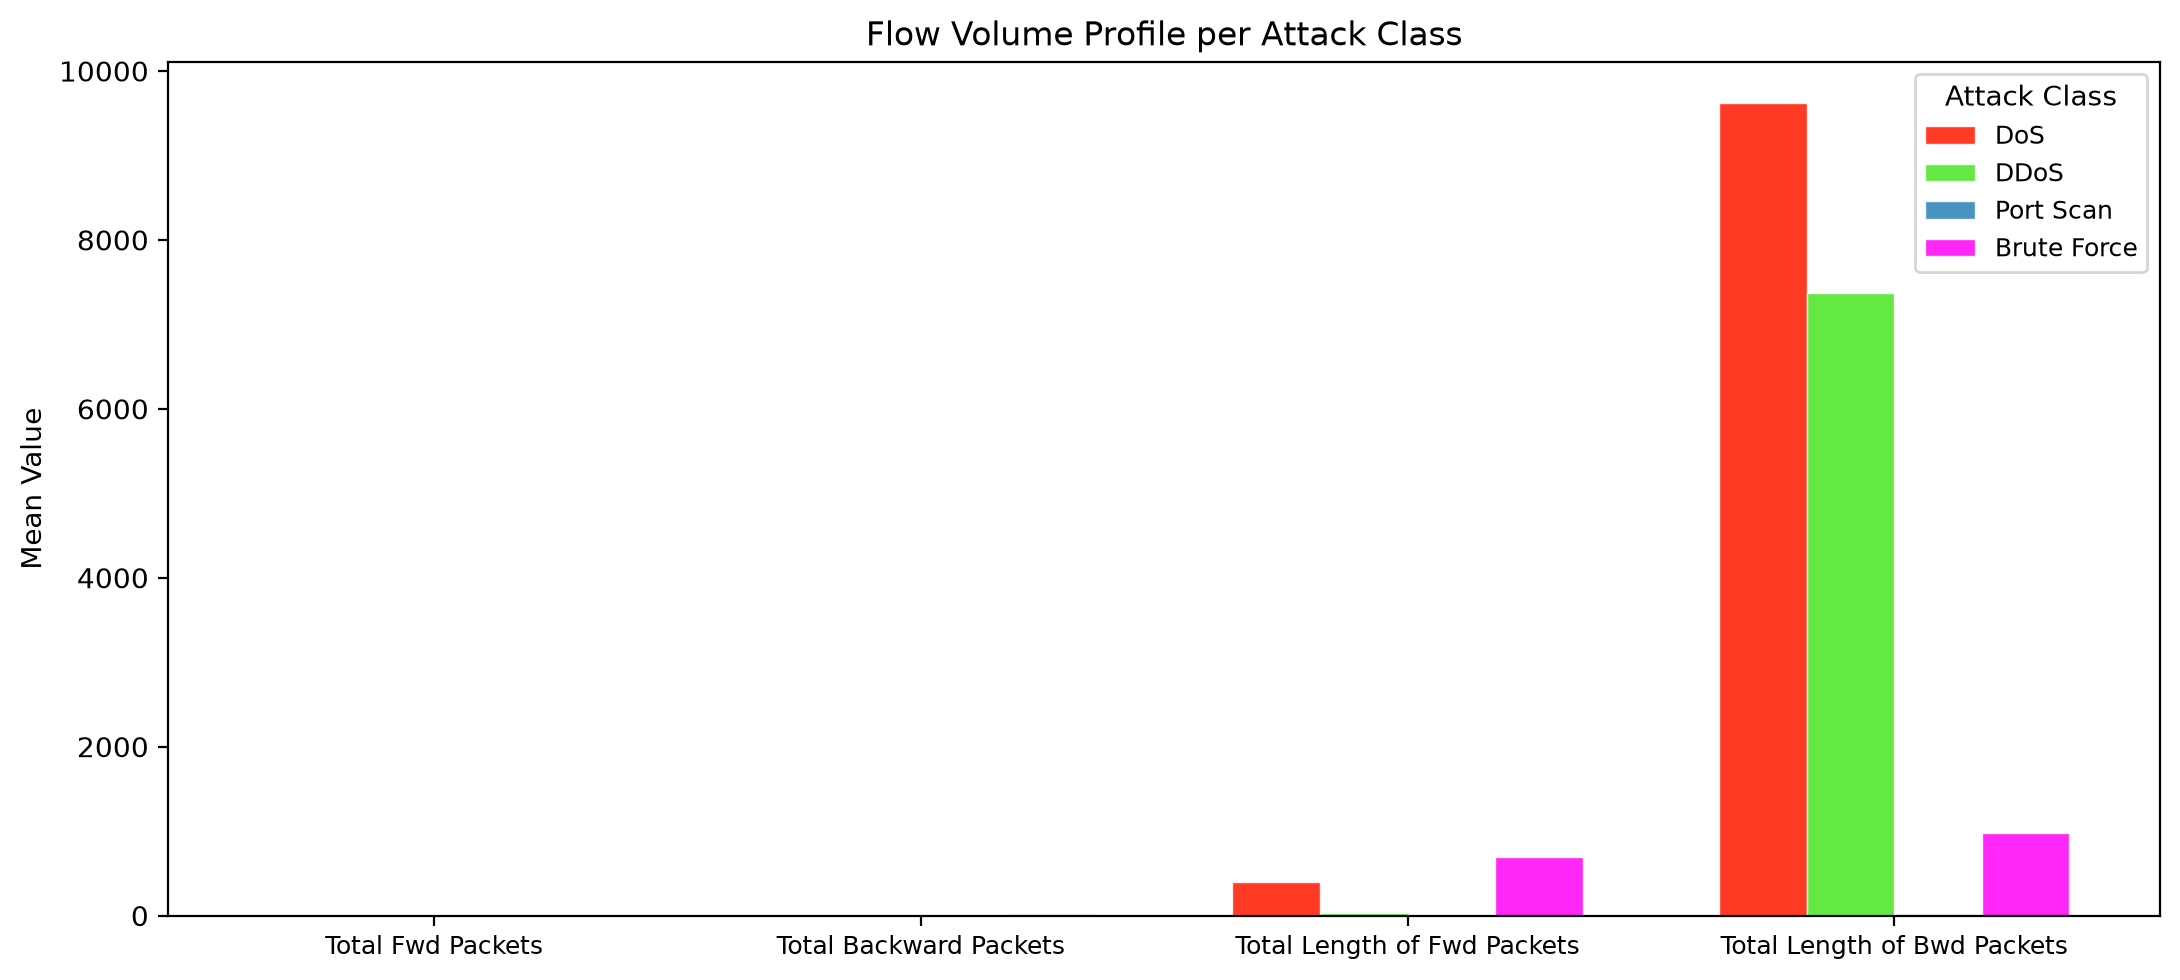

In [14]:
# ── 8. Flow volume profile ────────────────────────────────────────────────────
print("Plotting flow volume profile...")
vol_feats = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
]
vol_means = pd.DataFrame({
    label: df[vol_feats].replace([np.inf, -np.inf], np.nan).mean()
    for label, df in dfs.items()
})
 
x = np.arange(len(vol_feats))
width = 0.18
fig, ax = plt.subplots(figsize=(11, 5))
for i, (label, color) in enumerate(COLORS.items()):
    ax.bar(x + i * width, vol_means[label], width, label=label,
           color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
 
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(vol_feats, fontsize=9)
ax.set_ylabel('Mean Value')
ax.set_title('Flow Volume Profile per Attack Class', fontsize=12)
ax.legend(title='Attack Class', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_flow_volume_profile.png', bbox_inches='tight')
plt.show()

Plotting flag feature rates...


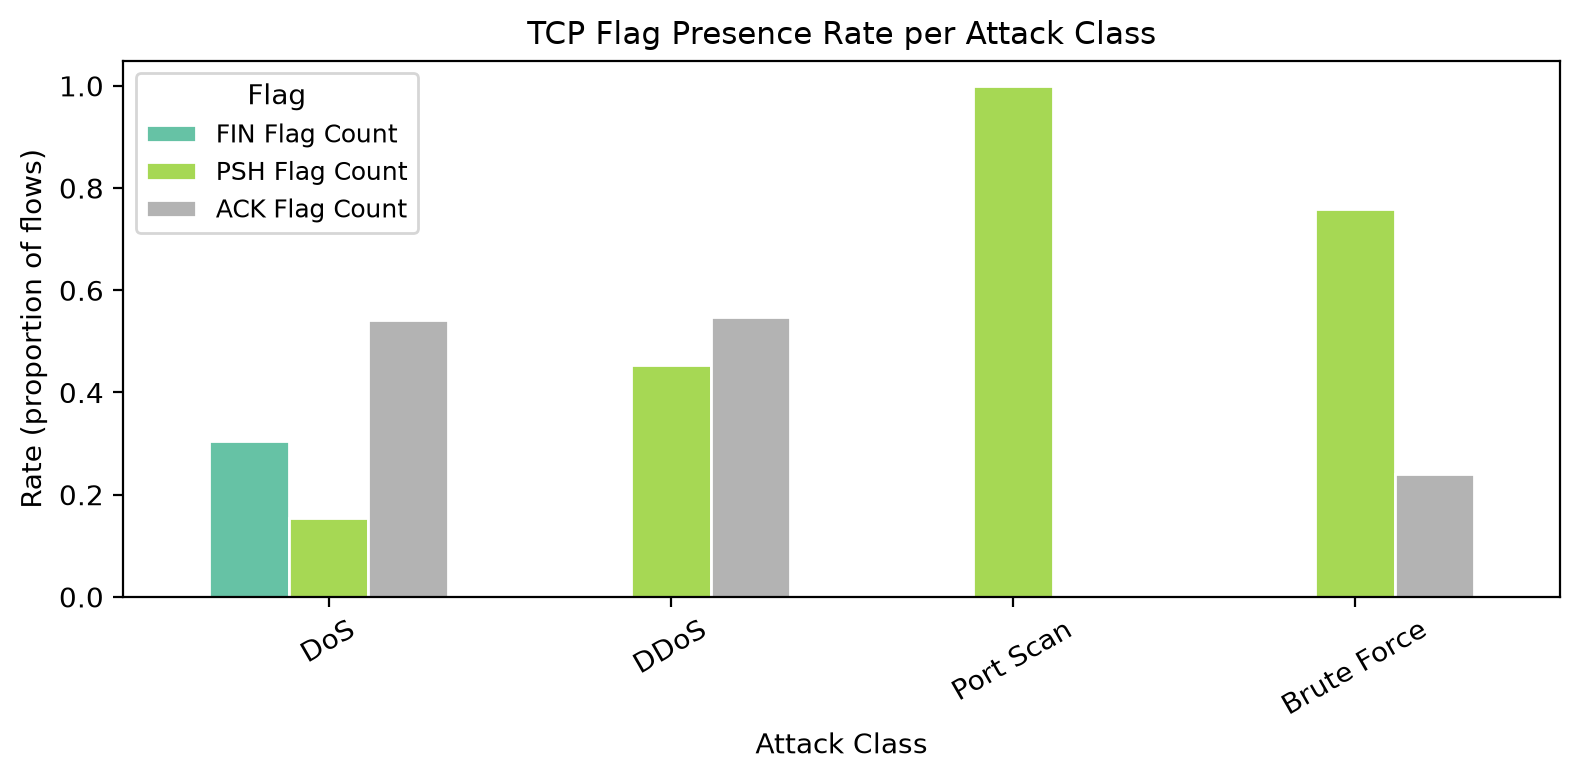


All plots saved to: AttackTypeEDAPlots/
Done.


In [ ]:

# ── 9. Flag feature analysis (binary features) ────────────────────────────────
print("Plotting flag feature rates...")
flag_feats = ['FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count']
flag_rates = pd.DataFrame({
    label: df[flag_feats].clip(upper=1).mean()
    for label, df in dfs.items()
})

fig, ax = plt.subplots(figsize=(8, 4))
flag_rates.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('TCP Flag Presence Rate per Attack Class', fontsize=11)
ax.set_ylabel('Rate (proportion of flows)')
ax.set_xlabel('Attack Class')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Flag', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_flag_rates.png', bbox_inches='tight')
plt.show()


Plotting KDE plots...


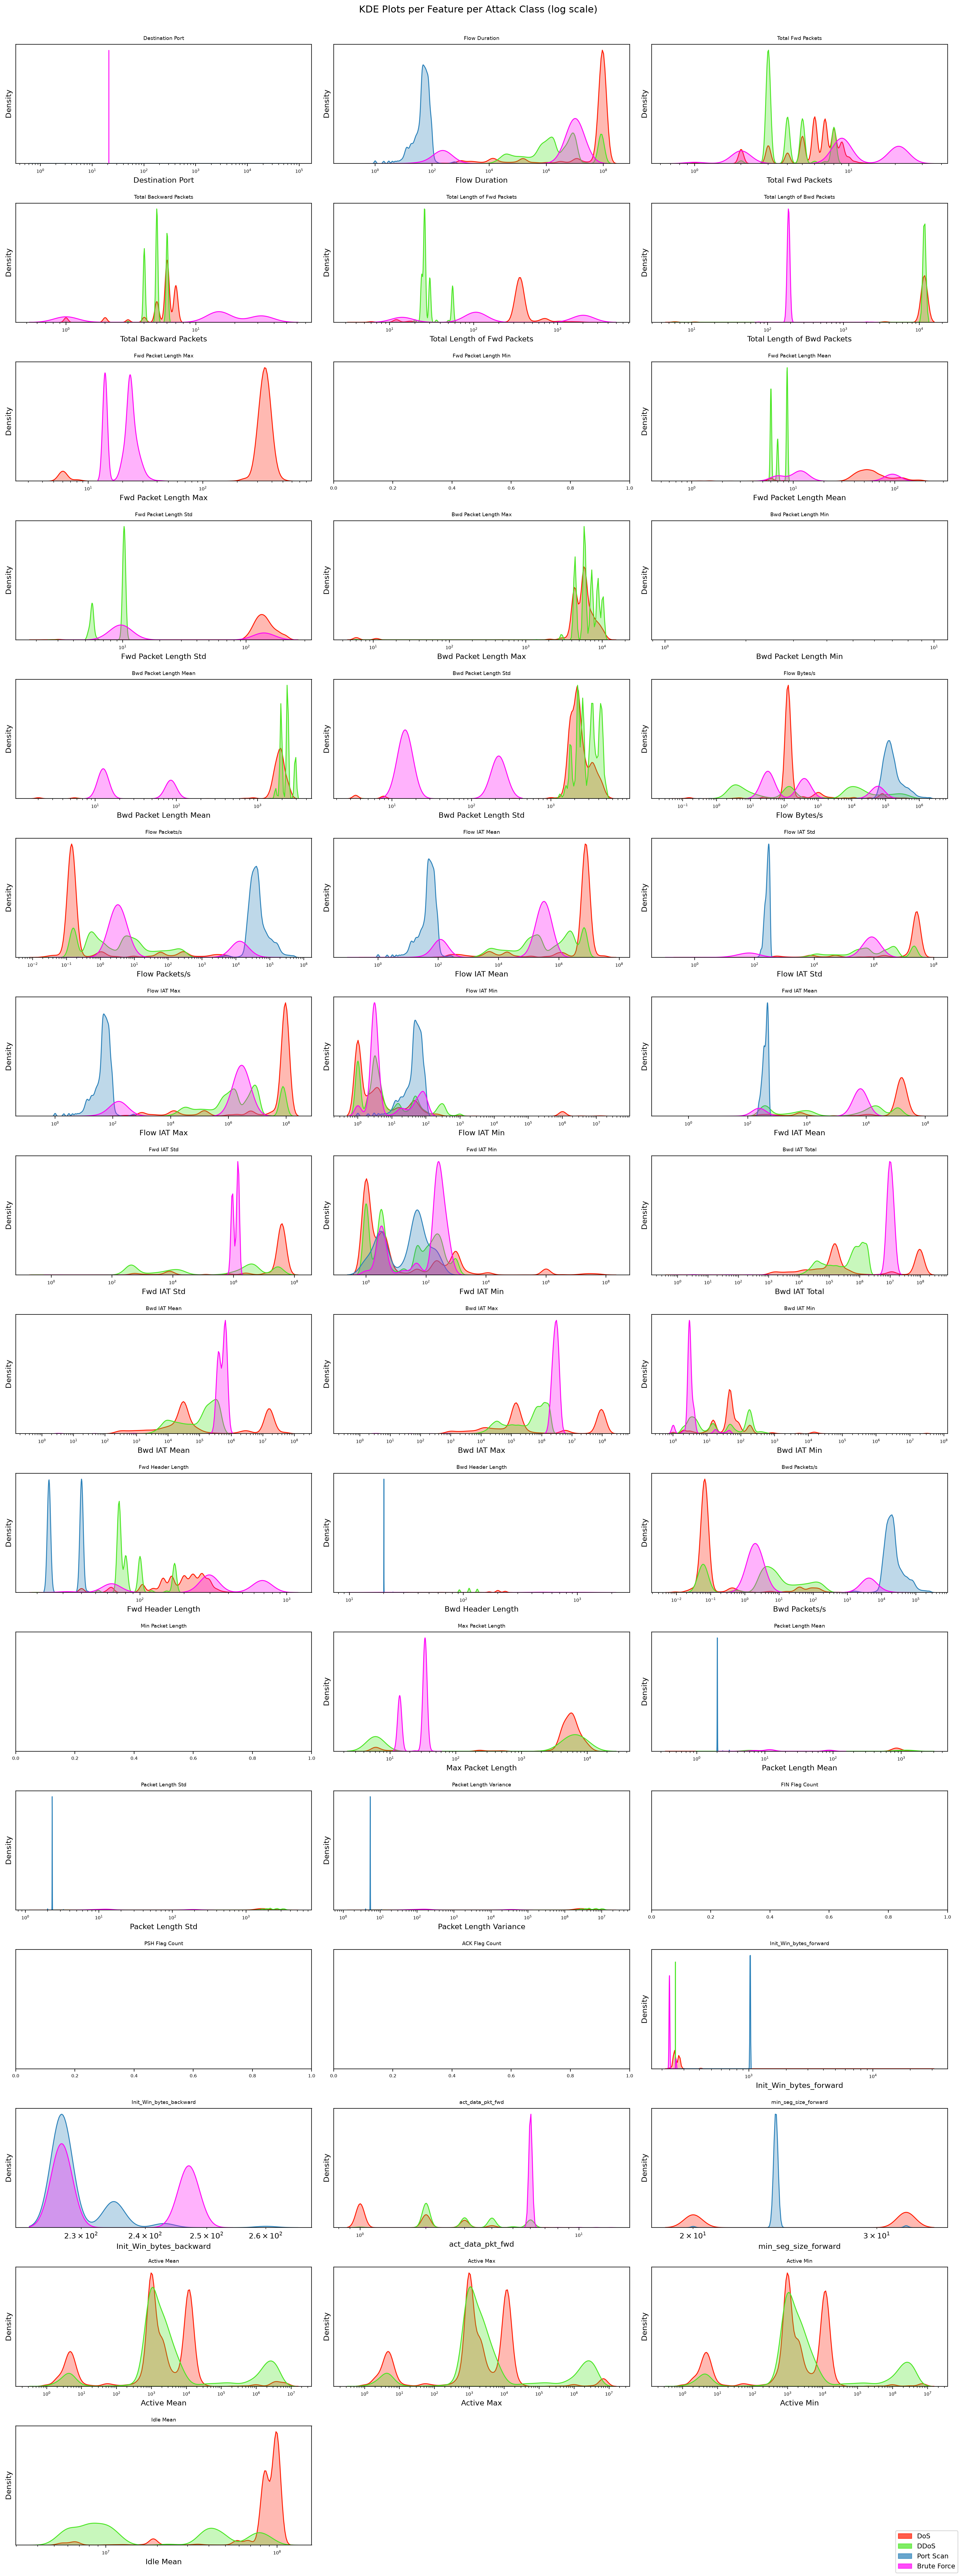


All plots saved to: AttackTypeEDAPlots/
Done.


In [17]:
# ── 10. KDE plots per feature per class ──────────────────────────────────────
print("Plotting KDE plots...")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for label, df in dfs.items():
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        vals = vals[vals < vals.quantile(0.99)]
        vals = vals[vals > 0]  # log scale needs positive values
        if len(vals) < 10:
            continue
        sns.kdeplot(vals, ax=ax, label=label, color=COLORS[label],
                    fill=True, alpha=0.3, linewidth=1.2, log_scale=True)
    ax.set_title(feat, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in COLORS.values()]
fig.legend(handles, COLORS.keys(), loc='lower right', fontsize=9)
fig.suptitle('KDE Plots per Feature per Attack Class (log scale)', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_kde_plots.png', bbox_inches='tight')
plt.show()

print(f"\nAll plots saved to: {OUTPUT_DIR}/")
print("Done.")